In [12]:
import numpy as np
import matplotlib.pyplot as plt

def fresh_grid(N=200):
    U = np.ones((N, N))
    V = np.zeros((N, N))
    c = N // 2
    V[c-10:c+10, c-10:c+10] = 1.0
    U[c-10:c+10, c-10:c+10] = 0.5
    return U, V

In [13]:
# average the four neighbors and subtract the center.
def laplacian(Z):
    return (np.roll(Z, 1, 0) + np.roll(Z, -1, 0)
          + np.roll(Z, 1, 1) + np.roll(Z, -1, 1)
          - 4 * Z)

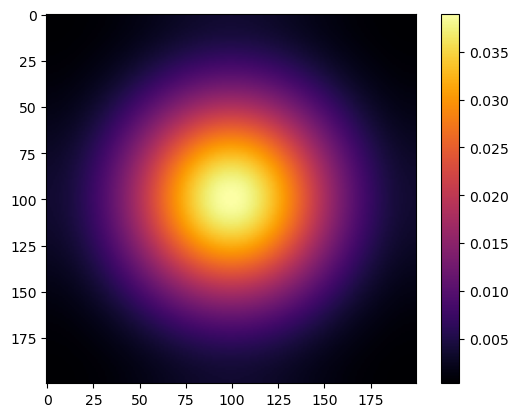

In [15]:
U,V = fresh_grid()
Dv = 0.08
for step in range(10000):
    V += Dv * laplacian(V)

plt.imshow(V, cmap='inferno')
plt.colorbar()
plt.show()

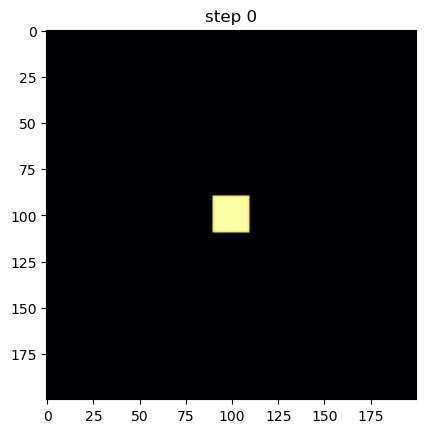

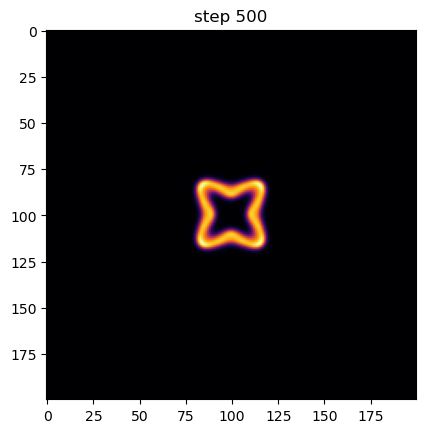

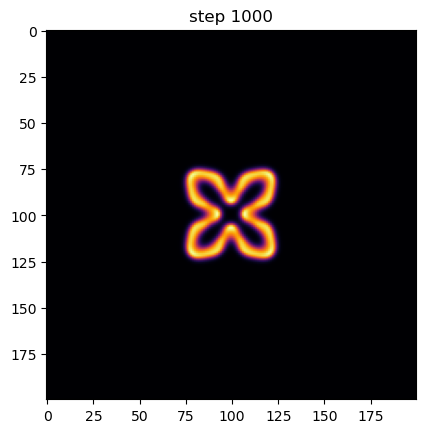

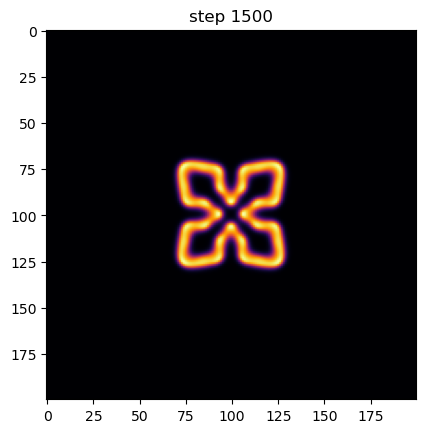

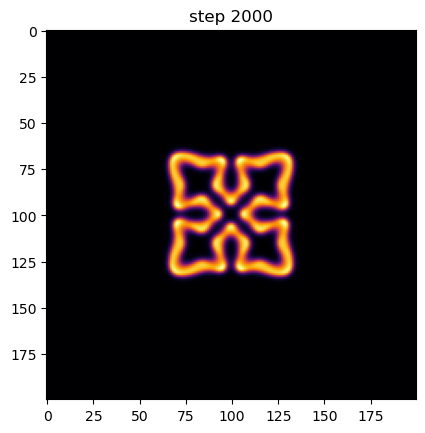

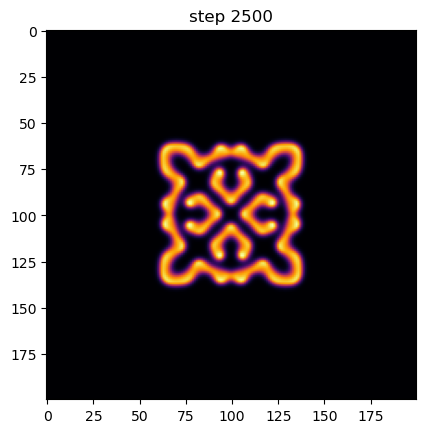

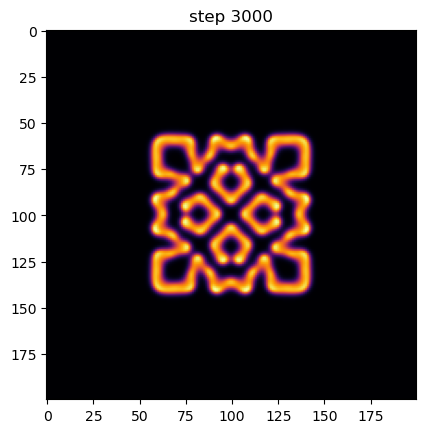

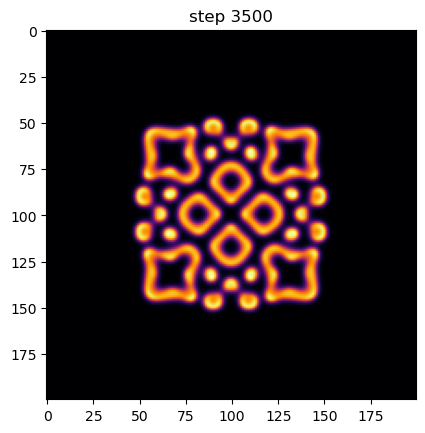

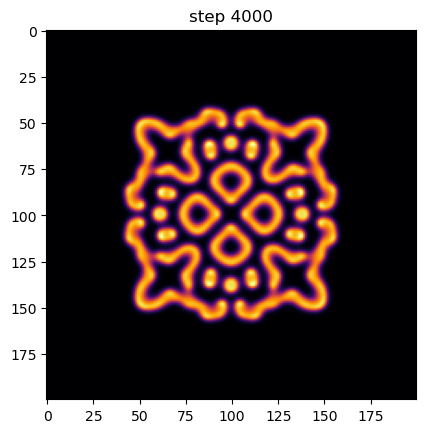

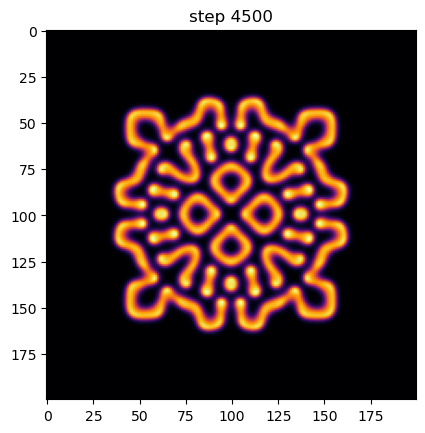

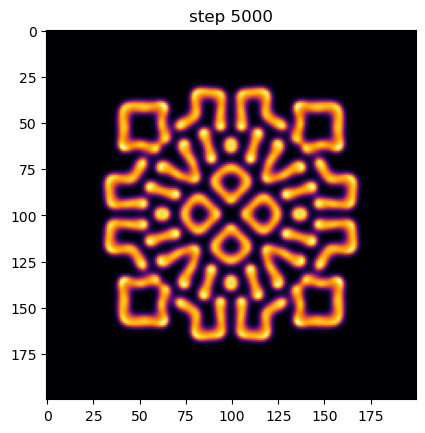

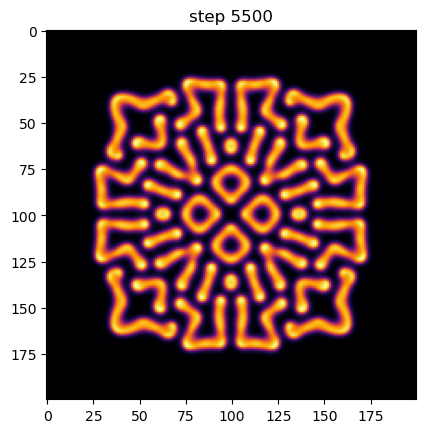

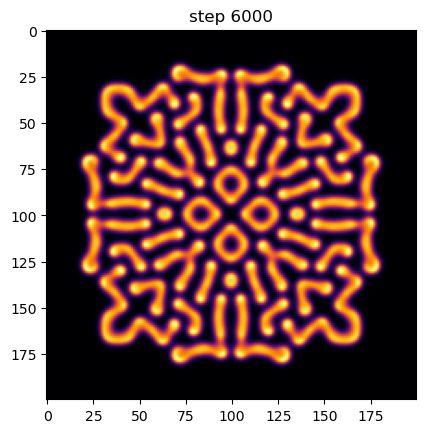

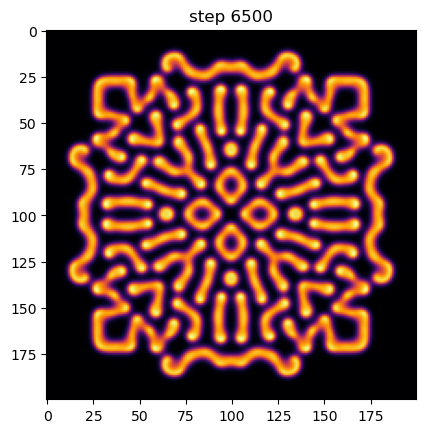

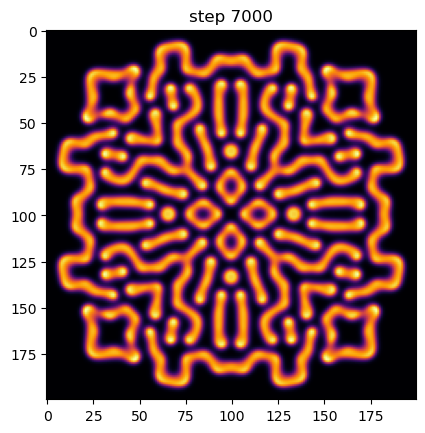

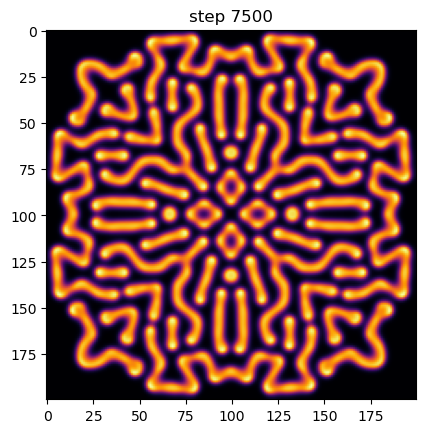

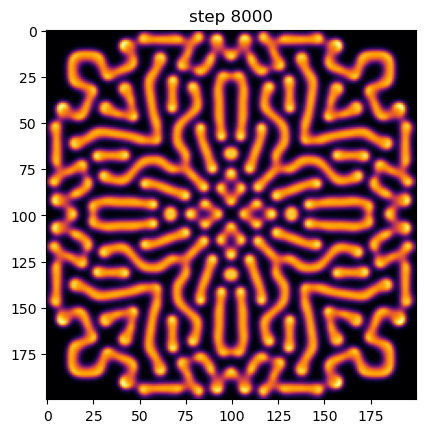

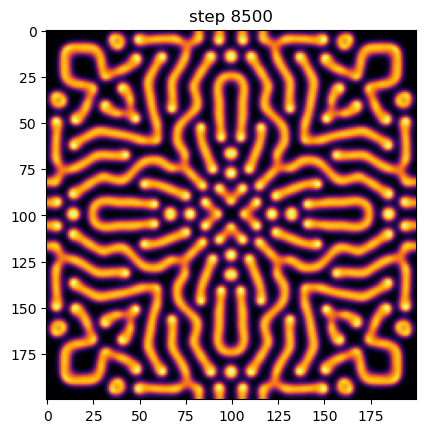

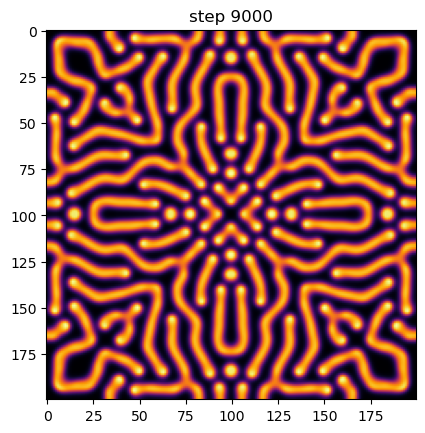

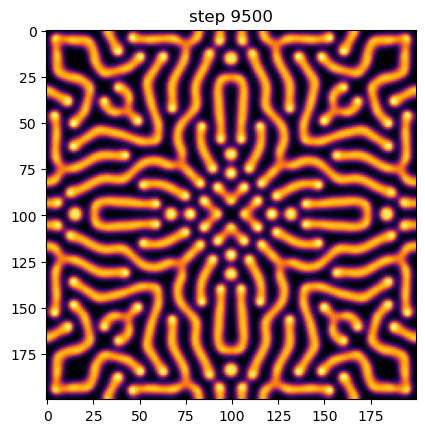

In [18]:
F = 0.040
k = 0.062
Du = 0.16
Dv = 0.08
U, V = fresh_grid()

for step in range(10000):
    Lu = laplacian(U)
    Lv = laplacian(V)
    uvv = U * V * V
    U += Du * Lu - uvv + F * (1 - U)
    V += Dv * Lv + uvv - (F + k) * V

    if step % 500 == 0:
        plt.imshow(V, cmap='inferno')
        plt.title(f"step {step}")
        plt.show()